# Kunci Jawaban - Linear Regression

- **Dataset:** Computer Hardware
- **Target:** `PRP`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Install library tambahan

Install `ucimlrepo` terlebih dahulu agar dataset dari UCI Machine Learning Repository bisa diambil langsung di Google Colab.

In [1]:
%pip install -q ucimlrepo

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, scatter plot, dan boxplot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE, regression plot, dan boxplot.

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `fetch_ucirepo`: mengambil dataset langsung dari UCI Machine Learning Repository.
- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [3]:
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [4]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [5]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Ambil dataset dari UCI

Ambil dataset Computer Hardware menggunakan ID dataset dari UCI.

In [6]:
hardware = fetch_ucirepo(id=29)

### Ambil data dari dataset

Simpan data Computer Hardware ke DataFrame bernama `df`.

In [7]:
df = hardware.data.features.copy()

### Tentukan kolom target

Tentukan kolom `PRP` sebagai target prediksi.

In [8]:
TARGET_COL = "PRP"

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom pada dataset.

In [9]:
df.shape

(209, 10)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki 209 baris dan 10 kolom.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat contoh isi data.

In [10]:
df.head()

,VendorName,ModelName,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
0,adviser,32/60,125,256,6000,256,16,128,198,199
1,amdahl,470v/7,29,8000,32000,32,8,32,269,253
2,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
3,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
4,amdahl,470v/7c,29,8000,16000,32,8,16,132,132


> Berdasarkan lima baris pertama, kolom apa yang menjadi target prediksi?

Jawaban: Kolom target prediksi adalah `PRP`.

> Kolom mana yang terlihat berisi teks?

Jawaban: Kolom `VendorName` dan `ModelName` berisi teks.

## 3 - Data Understanding

### Tampilkan informasi dataset

Tampilkan informasi struktur dataset menggunakan `info()`.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   VendorName  209 non-null    object
 1   ModelName   209 non-null    object
 2   MYCT        209 non-null    int64 
 3   MMIN        209 non-null    int64 
 4   MMAX        209 non-null    int64 
 5   CACH        209 non-null    int64 
 6   CHMIN       209 non-null    int64 
 7   CHMAX       209 non-null    int64 
 8   PRP         209 non-null    int64 
 9   ERP         209 non-null    int64 
dtypes: int64(8), object(2)
memory usage: 16.5+ KB


> Berdasarkan output `info()`, apa tipe data yang muncul pada dataset?

Jawaban: Dataset memiliki tipe data `object` dan `int64`.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak. Semua kolom memiliki 209 non-null, sama dengan jumlah baris dataset.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [12]:
df.isna().sum()

VendorName    0
ModelName     0
MYCT          0
MMIN          0
MMAX          0
CACH          0
CHMIN         0
CHMAX         0
PRP           0
ERP           0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris duplikat penuh pada dataset.

In [13]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh adalah 0.

### Tampilkan statistik deskriptif

Tampilkan statistik deskriptif untuk kolom numerik dan kategori.

In [14]:
df.describe(include="all")

,VendorName,ModelName,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
count,209,209,209.000,209.000,209.000,209.000,209.000,209.000,209.000,209.000
unique,30,209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ibm,32/60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,32,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,203.823,2867.981,11796.153,25.206,4.699,18.268,105.622,99.330
std,NaN,NaN,260.263,3878.743,11726.564,40.629,6.816,25.997,160.831,154.757
min,NaN,NaN,17.000,64.000,64.000,0.000,0.000,0.000,6.000,15.000
25%,NaN,NaN,50.000,768.000,4000.000,0.000,1.000,5.000,27.000,28.000
50%,NaN,NaN,110.000,2000.000,8000.000,8.000,2.000,8.000,50.000,45.000
75%,NaN,NaN,225.000,4000.000,16000.000,32.000,6.000,24.000,113.000,101.000


> Berdasarkan statistik deskriptif, berapa rata-rata target `PRP`?

Jawaban: Rata-rata target `PRP` sekitar 105.622.

> Berdasarkan statistik deskriptif, vendor apa yang paling sering muncul?

Jawaban: Vendor yang paling sering muncul adalah `ibm`.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh agar data lebih bersih.

In [15]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index setelah proses cleaning.

In [16]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah proses cleaning.

In [17]:
df_clean.shape

(209, 10)

> Berdasarkan output, berapa ukuran dataset setelah duplikat dihapus?

Jawaban: Ukuran dataset tetap 209 baris dan 10 kolom.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat penuh setelah cleaning.

In [18]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak ada baris duplikat setelah cleaning.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Tampilkan statistik deskriptif khusus untuk target `PRP`.

In [19]:
df_clean[TARGET_COL].describe()

count    209.000
mean     105.622
std      160.831
min        6.000
25%       27.000
50%       50.000
75%      113.000
max     1150.000
Name: PRP, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Mean target sekitar 105.622, minimum 6.000, dan maksimum 1150.000.

### Buat histogram target

Gunakan histogram dengan KDE untuk melihat distribusi target `PRP`.

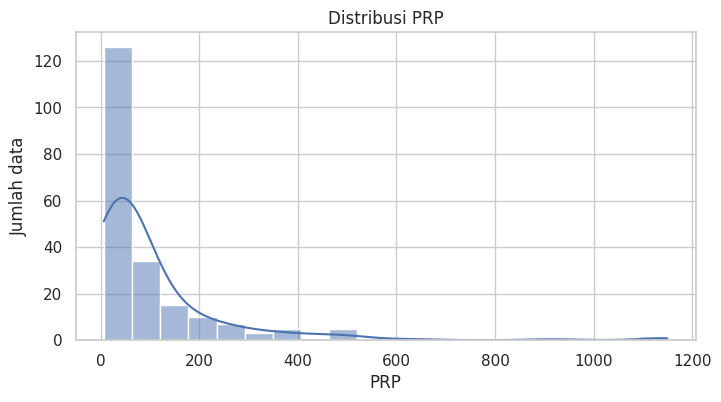

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=20, kde=True)
plt.title("Distribusi PRP")
plt.xlabel("PRP")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Nilai target paling banyak muncul pada rentang rendah, sekitar 6.000 sampai 63.200.

> Apakah distribusi target terlihat simetris atau cenderung miring?

Jawaban: Distribusi target cenderung miring ke kanan karena ada nilai PRP yang jauh lebih tinggi.

### Hitung korelasi fitur hardware dengan target

Hitung korelasi fitur hardware numerik terhadap target tanpa memakai `ERP`.

In [21]:
modeling_columns = df_clean.drop(columns=["VendorName", "ModelName", "ERP"])
numeric_corr = modeling_columns.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
numeric_corr

MMAX     0.863
MMIN     0.795
CACH     0.663
CHMIN    0.609
CHMAX    0.605
MYCT    -0.307
Name: PRP, dtype: float64

> Berdasarkan output korelasi, fitur apa yang memiliki korelasi positif paling tinggi terhadap target?

Jawaban: Fitur `MMAX` memiliki korelasi positif paling tinggi terhadap target.

> Fitur apa yang memiliki korelasi negatif terhadap target?

Jawaban: Fitur `MYCT` memiliki korelasi negatif terhadap target.

### Buat bar plot korelasi numerik

Gunakan bar plot untuk melihat kekuatan korelasi fitur numerik dengan target.

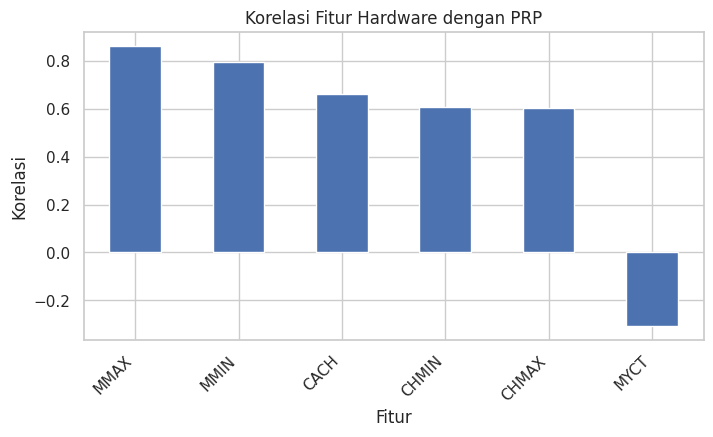

In [22]:
plt.figure(figsize=(8, 4))
numeric_corr.plot(kind="bar")
plt.title("Korelasi Fitur Hardware dengan PRP")
plt.xlabel("Fitur")
plt.ylabel("Korelasi")
plt.xticks(rotation=45, ha="right")
plt.show()

> Berdasarkan bar plot, fitur mana yang paling positif hubungannya dengan target?

Jawaban: `MMAX` paling positif hubungannya dengan target.

> Fitur mana yang memiliki arah korelasi negatif?

Jawaban: `MYCT` memiliki arah korelasi negatif.

### Buat scatter plot MMAX dan target

Gunakan scatter plot dengan garis regresi untuk melihat hubungan `MMAX` dengan target.

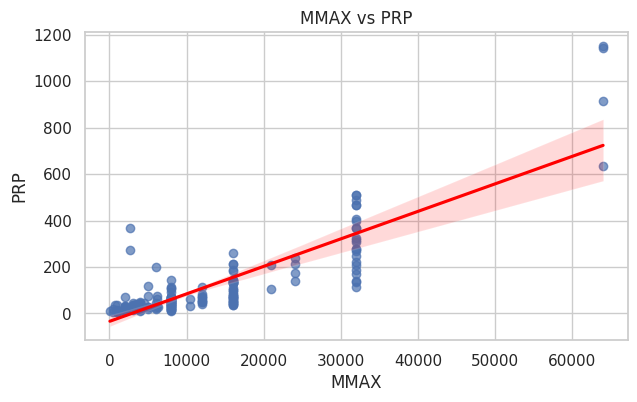

In [23]:
plt.figure(figsize=(7, 4))
sns.regplot(data=df_clean, x="MMAX", y=TARGET_COL, scatter_kws={"alpha": 0.7}, line_kws={"color": "red"})
plt.title("MMAX vs PRP")
plt.xlabel("MMAX")
plt.ylabel("PRP")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `MMAX` dengan target?

Jawaban: Polanya cenderung positif; semakin tinggi `MMAX`, nilai PRP cenderung lebih tinggi.

> Apakah garis regresi menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis regresi menunjukkan arah hubungan positif.

### Buat boxplot PRP berdasarkan vendor utama

Gunakan boxplot untuk membandingkan PRP pada beberapa vendor yang paling sering muncul.

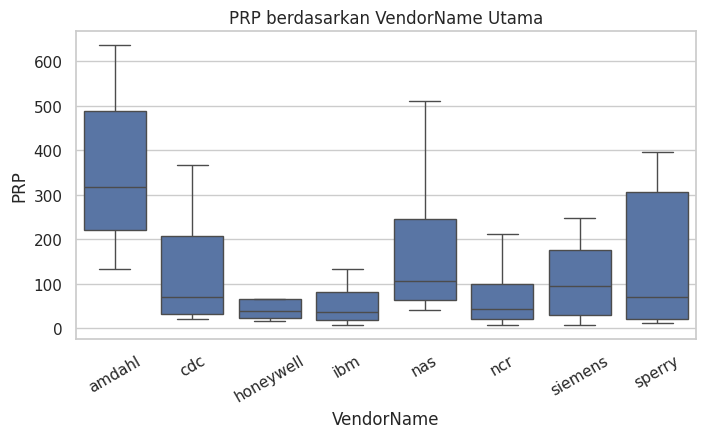

In [24]:
top_vendors = df_clean["VendorName"].value_counts().head(8).index
vendor_subset = df_clean[df_clean["VendorName"].isin(top_vendors)]

plt.figure(figsize=(8, 4))
sns.boxplot(data=vendor_subset, x="VendorName", y=TARGET_COL, showfliers=False)
plt.title("PRP berdasarkan VendorName Utama")
plt.xlabel("VendorName")
plt.ylabel("PRP")
plt.xticks(rotation=30)
plt.show()

> Berdasarkan boxplot, vendor utama mana yang cenderung memiliki PRP lebih tinggi?

Jawaban: `amdahl` cenderung memiliki PRP lebih tinggi dibandingkan vendor utama lain.

> Mengapa boxplot lebih tepat daripada scatter plot untuk `VendorName`?

Jawaban: Boxplot lebih tepat karena `VendorName` adalah kolom kategori.

## 6 - Feature dan Target

### Pisahkan fitur awal

Pisahkan fitur hardware dengan menghapus target, kolom teks, dan `ERP`.

In [25]:
X_raw_model = df_clean.drop(columns=[TARGET_COL, "VendorName", "ModelName", "ERP"])

### Pisahkan target

Simpan kolom target ke dalam variabel `y`.

In [26]:
y = df_clean[TARGET_COL]

### Gunakan fitur numerik

Gunakan fitur numerik yang sudah tersedia setelah kolom teks dihapus.

In [27]:
X = X_raw_model.copy()

### Tampilkan ukuran fitur

Tampilkan ukuran `X` yang akan digunakan untuk modeling.

In [28]:
X.shape

(209, 6)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X`?

Jawaban: `X` memiliki 209 baris dan 6 fitur.

### Tampilkan ukuran target

Tampilkan ukuran `y` sebagai target model.

In [29]:
y.shape

(209,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki 209 nilai target.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [30]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji sebanyak 20% dan data latih sebanyak 80%.

### Bagi data train dan test

Bagi fitur dan target menjadi data train dan data test.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Tampilkan ukuran fitur pada data train.

In [32]:
X_train.shape

(167, 6)

### Tampilkan ukuran X_test

Tampilkan ukuran fitur pada data test.

In [33]:
X_test.shape

(42, 6)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki 167 baris dan data test memiliki 42 baris.

## 8 - Feature Scaling

### Buat object scaler

Buat object `StandardScaler` untuk menyamakan skala fitur.

In [34]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler pada data train, lalu ubah data train ke skala standar.

In [35]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Ubah data test menggunakan scaler yang sudah di-fit pada data train.

In [36]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [37]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [38]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan?

Jawaban: Output menampilkan object `LinearRegression()`, yang berarti model berhasil dibuat dan dilatih.

### Tampilkan intercept model

Tampilkan nilai intercept dari model Linear Regression.

In [39]:
model.intercept_

np.float64(99.44910179640719)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar 99.449.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel.

In [40]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_table

,Feature,Coefficient
2,MMAX,64.575
1,MMIN,37.318
5,CHMAX,32.387
3,CACH,25.748
0,MYCT,11.425
4,CHMIN,2.367


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar?

Jawaban: Fitur `MMAX` memiliki koefisien positif terbesar.

> Apakah ada koefisien fitur yang bernilai negatif?

Jawaban: Tidak ada koefisien fitur yang bernilai negatif pada model ini.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk membuat prediksi pada data train.

In [41]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk membuat prediksi pada data test.

In [42]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama pada data test.

In [43]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
}).head()

prediction_preview

,Actual,Predicted
0,274,101.065
1,30,-0.231
2,22,8.916
3,915,730.280
4,16,41.039


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dengan nilai aktual?

Jawaban: Baris ketiga terlihat paling dekat karena actual 22.000 dan predicted sekitar 8.916.

> Prediksi mana yang terlihat paling jauh dari nilai aktual?

Jawaban: Baris keempat terlihat paling jauh karena actual 915.000 dan predicted sekitar 730.280.

### Hitung MAE train

Hitung MAE pada data train.

In [44]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

35.12200634651686

### Hitung MAE test

Hitung MAE pada data test.

In [45]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

48.068801347004765

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar 48.069.

### Hitung RMSE train

Hitung RMSE pada data train.

In [46]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(55.836000084445324)

### Hitung RMSE test

Hitung RMSE pada data test.

In [47]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(75.05376843166006)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar 75.054.

### Hitung R2 train

Hitung R2 Score pada data train.

In [48]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.8378284557995717

### Hitung R2 test

Hitung R2 Score pada data test.

In [49]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.8893455830696775

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar 0.889.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 Score untuk data train dan data test.

In [50]:
evaluation_table = pd.DataFrame({
    "Data": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2 Score": [r2_train, r2_test]
})

evaluation_table

,Data,MAE,RMSE,R2 Score
0,Train,35.122,55.836,0.838
1,Test,48.069,75.054,0.889


> Berdasarkan tabel evaluasi, bagaimana perbandingan MAE train dan MAE test?

Jawaban: MAE test sekitar 36.86% lebih tinggi daripada MAE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan RMSE train dan RMSE test?

Jawaban: RMSE test sekitar 34.42% lebih tinggi daripada RMSE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan R2 train dan R2 test?

Jawaban: R2 test sekitar 6.15% lebih tinggi daripada R2 train.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk membandingkan nilai aktual dan prediksi pada data test.

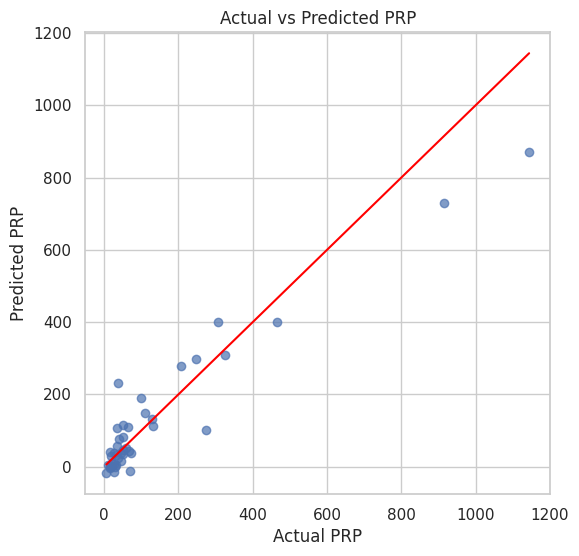

In [51]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.title("Actual vs Predicted PRP")
plt.xlabel("Actual PRP")
plt.ylabel("Predicted PRP")
plt.show()

## 11 - Kesimpulan

Dataset Computer Hardware digunakan untuk memprediksi `PRP` berdasarkan spesifikasi hardware komputer. Dataset memiliki 209 baris dan 10 kolom. Data tidak memiliki missing value dan memiliki 0 baris duplikat penuh.

EDA menunjukkan bahwa target `PRP` cenderung miring ke kanan. Fitur numerik dengan korelasi positif paling tinggi terhadap target adalah `MMAX`, sedangkan fitur dengan korelasi negatif terhadap target adalah `MYCT`. Kolom `VendorName`, `ModelName`, dan `ERP` dihapus sebelum modeling.

Data dibagi menjadi 80% data train dan 20% data test. Berdasarkan evaluasi, MAE test bernilai sekitar 48.069, RMSE test sekitar 75.054, dan R2 test sekitar 0.889.